# Real vs generated scRNA-seq: differential expression comparison

DLPFC sample **BR6471mid**. Compares cluster-level differential expression between the
real dataset and a generated (synthetic) dataset processed through an identical pipeline.

Both datasets are concatenated, QC'd, normalised, embedded and clustered **jointly**, so
that Leiden cluster labels are directly comparable between them. Differential expression
is then run separately within each dataset, and the resulting gene sets are compared
cluster by cluster.

All artefacts are written under `output/`:

| Path | Contents |
| --- | --- |
| `output/figures/` | Every figure, prefixed `00_`, `01_`, ... in notebook order |
| `output/tables/` | Differential expression CSVs |
| `output/` | `.h5ad` exports for downstream monocle3 analysis |

## Setup

In [38]:
# Positron's bundled ipykernel ships an outdated typing_extensions that shadows
# the venv copy; put the venv's site-packages first before any heavy imports.
import site
import sys

for path in site.getsitepackages():
    if path in sys.path:
        sys.path.remove(path)
    sys.path.insert(0, path)
sys.modules.pop("typing_extensions", None)

import anndata as ad
import numpy as np
import pandas as pd
import scanpy as sc
import seaborn as sns
from matplotlib import pyplot as plt
from matplotlib_venn import venn2
from scipy.stats import hypergeom

from pathlib import Path

# Make the project root (the folder containing `src/`) importable.
project_root = next(
    p for p in [Path.cwd(), *Path.cwd().parents] if (p / "src" / "input_output.py").is_file()
)
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

from src.input_output import read_scRNA_data

data_dir = project_root / "data"

# Output layout: figures/ (numbered in notebook order), tables/ (CSV), h5ad at top level.
out_dir = project_root / "output"
fig_dir = out_dir / "figures"
tbl_dir = out_dir / "tables"
for d in (out_dir, fig_dir, tbl_dir):
    d.mkdir(parents=True, exist_ok=True)

sc.settings.set_figure_params(dpi=80, facecolor="white", frameon=True)
sc.settings.verbosity = 2  # errors (0), warnings (1), info (2), hints (3)


def _resolve_fig(obj=None):
    """Best-effort Figure extraction from a scanpy or seaborn return value."""
    if isinstance(obj, plt.Figure):
        return obj
    if obj is None:
        return plt.gcf()
    if isinstance(getattr(obj, "figure", None), plt.Figure):  # Axes, seaborn >= 0.11.2 grids
        return obj.figure
    if isinstance(getattr(obj, "fig", None), plt.Figure):  # older seaborn grids
        return obj.fig
    if isinstance(obj, dict):
        obj = list(obj.values())
    if isinstance(obj, (list, tuple, np.ndarray)) and len(obj):
        return _resolve_fig(obj[0])
    return plt.gcf()


def save_fig(index, name, obj=None, ext="png", dpi=300):
    """Save a figure to output/figures as `<index>_<name>.<ext>`, e.g. `00_qc_violins.png`.

    `index` is passed explicitly rather than auto-incremented, so re-running one cell
    overwrites just its own file instead of renumbering everything downstream.
    `obj` may be a Figure, Axes, seaborn grid, or None to use the current figure.
    """
    path = fig_dir / f"{index:02d}_{name}.{ext}"
    _resolve_fig(obj).savefig(path, dpi=dpi, bbox_inches="tight")
    print(f"saved {path.relative_to(project_root)}")

<positron-console-cell-38>:41: FutureWarning: The method set_figure_params is deprecated and will be removed in the future. Use :func:`scanpy.set_figure_params` instead


## Load and combine the two datasets

`join="inner"` keeps the genes shared by both objects; `dataset_name` records the origin
of every cell.

In [26]:
adata_real = read_scRNA_data(
    str(data_dir / "br6471mid_real_5658x23973.h5ad"), "h5ad", "br6471mid_real"
)
adata_gen = read_scRNA_data(
    str(data_dir / "br6471mid_gen_5657x23973.h5ad"), "h5ad", "br6471mid_gen"
)

adata = ad.concat(
    {"br6471mid_real": adata_real, "br6471mid_gen": adata_gen},
    label="dataset_name",
    join="inner",
)
adata.obs_names_make_unique()
adata.var_names_make_unique()

adata

AnnData object with n_obs × n_vars = 11315 × 23973
    obs: 'dataset_name'
    layers: None (.X)

## Quality control

Mitochondrial, ribosomal and haemoglobin gene sets are flagged, QC metrics computed, and
cells filtered on gene count and mitochondrial fraction. QC distributions are shown
before and after filtering. See https://www.sc-best-practices.org/ for the rationale.

In [27]:
# mitochondrial genes ("MT-" for human), ribosomal genes, haemoglobin genes
adata.var["mt"] = adata.var_names.str.startswith("MT-")
adata.var["ribo"] = adata.var_names.str.startswith(("RPS", "RPL"))
adata.var["hb"] = adata.var_names.str.contains("^HB[^(P)]")

sc.pp.calculate_qc_metrics(
    adata, qc_vars=["mt", "ribo", "hb"], inplace=True, log1p=True, percent_top=[20]
)

saved output\figures\00_qc_total_counts_before_filtering.png
saved output\figures\01_qc_violins_before_filtering.png
saved output\figures\02_qc_counts_vs_genes_before_filtering.png


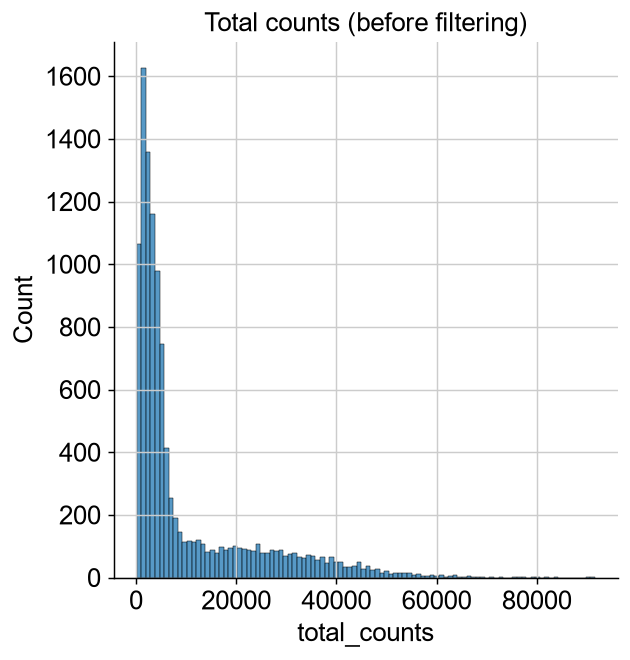

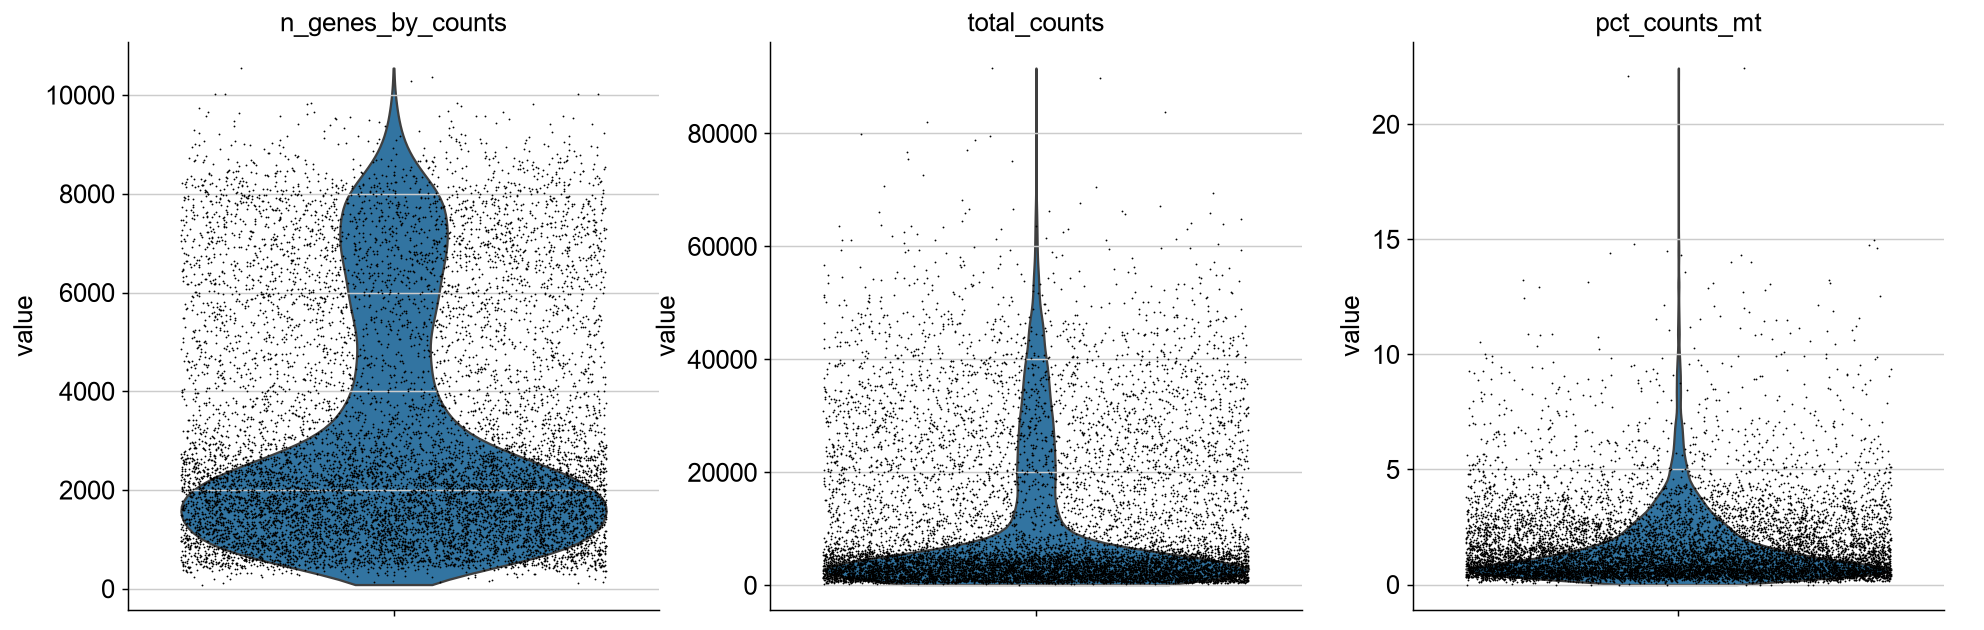

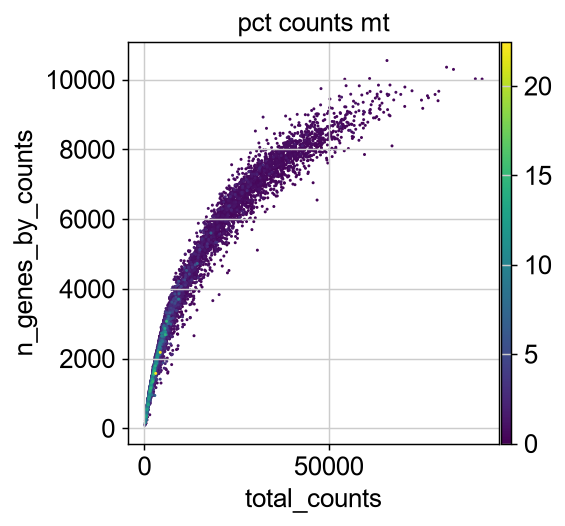

In [28]:
def plot_qc(adata, stage, index):
    """Total-count distribution, per-metric violins and a count-vs-genes scatter.

    Writes three figures numbered `index`, `index + 1`, `index + 2`.
    """
    slug = stage.replace(" ", "_")

    counts = sns.displot(adata.obs["total_counts"], bins=100, kde=False)
    counts.set(title=f"Total counts ({stage})")
    save_fig(index, f"qc_total_counts_{slug}", counts)

    violins = sc.pl.violin(
        adata,
        ["n_genes_by_counts", "total_counts", "pct_counts_mt"],
        jitter=0.4,
        multi_panel=True,
        show=False,
    )
    save_fig(index + 1, f"qc_violins_{slug}", violins)

    scatter = sc.pl.scatter(
        adata, "total_counts", "n_genes_by_counts", color="pct_counts_mt", show=False
    )
    save_fig(index + 2, f"qc_counts_vs_genes_{slug}", scatter)


plot_qc(adata, "before filtering", index=0)

saved output\figures\03_qc_total_counts_after_filtering.png
saved output\figures\04_qc_violins_after_filtering.png
saved output\figures\05_qc_counts_vs_genes_after_filtering.png


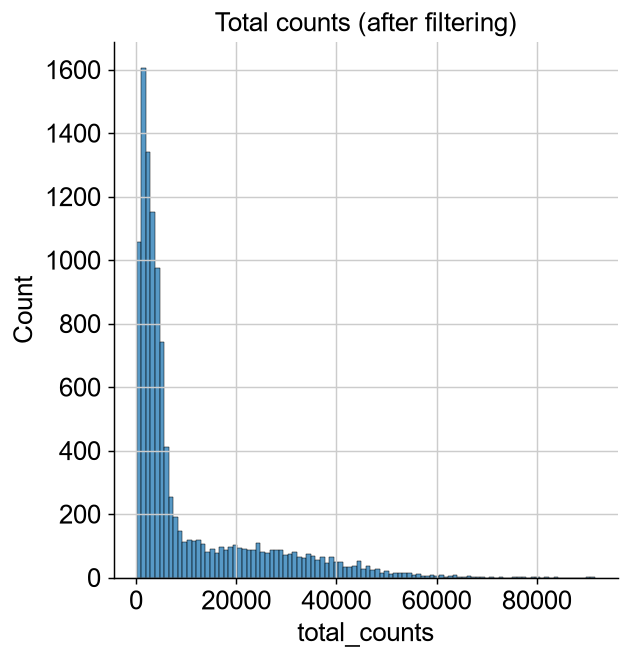

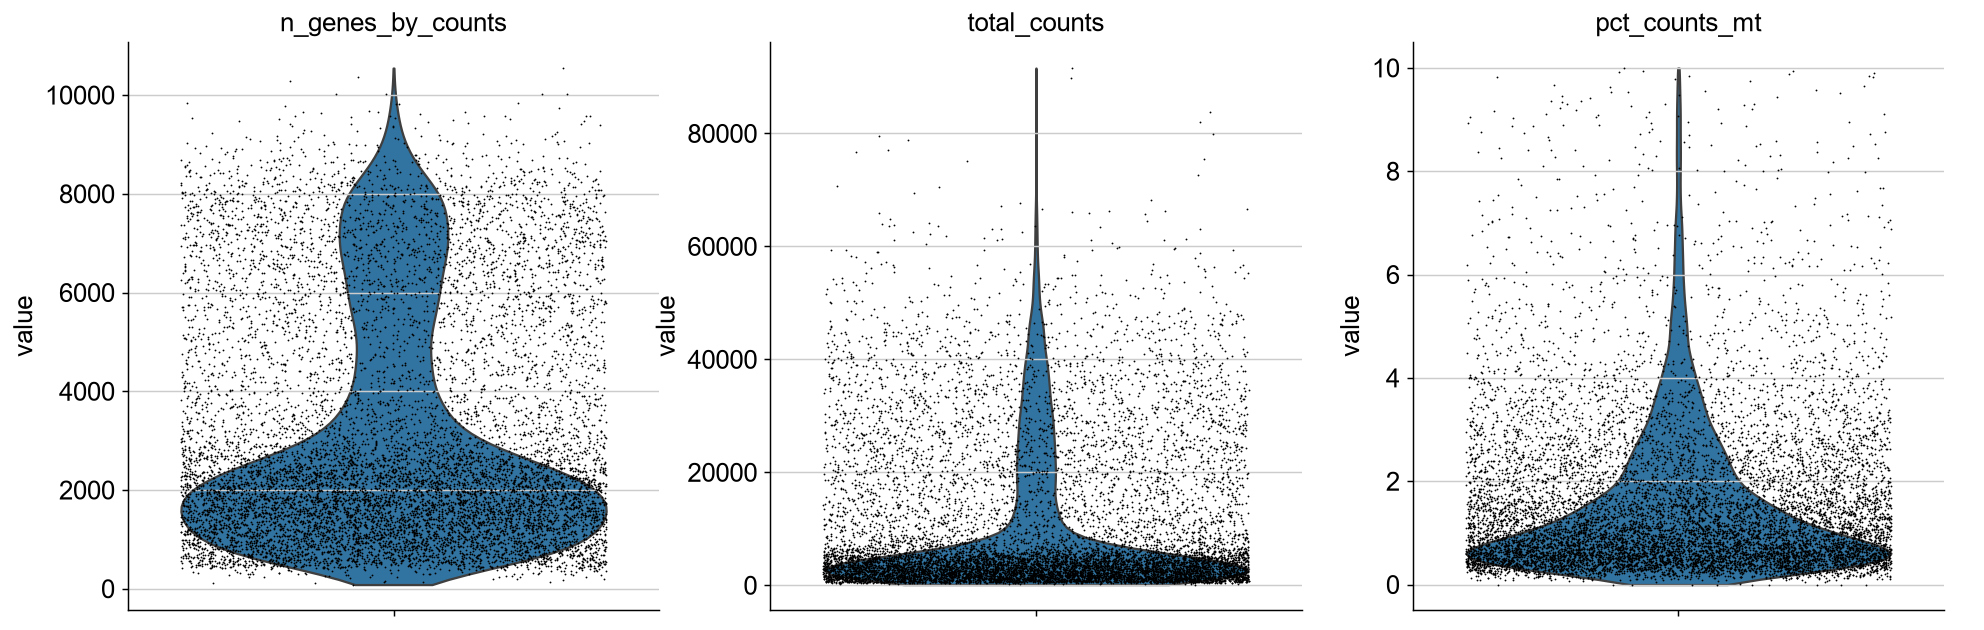

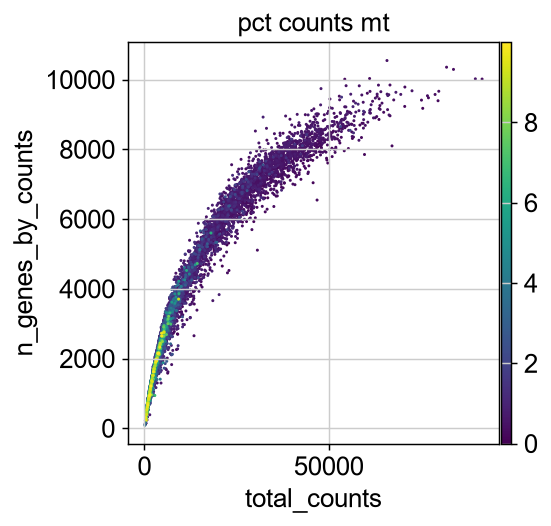

In [29]:
adata = adata[adata.obs["n_genes_by_counts"] < 18500]
adata = adata[adata.obs["n_genes_by_counts"] > 0]
adata = adata[adata.obs["pct_counts_mt"] < 10]

plot_qc(adata, "after filtering", index=3)

## Normalisation

Raw counts are kept in `layers["counts"]`. `normalize_total` with `target_sum=None`
scales each cell to the median total count, then `log1p` applies the shifted logarithm.

<positron-console-cell-30>:1: ImplicitModificationWarning: Setting element `.layers['counts']` of view, initializing view as actual.


normalizing counts per cell
    finished (0:00:00)
saved output\figures\06_normalisation_total_counts_vs_log.png


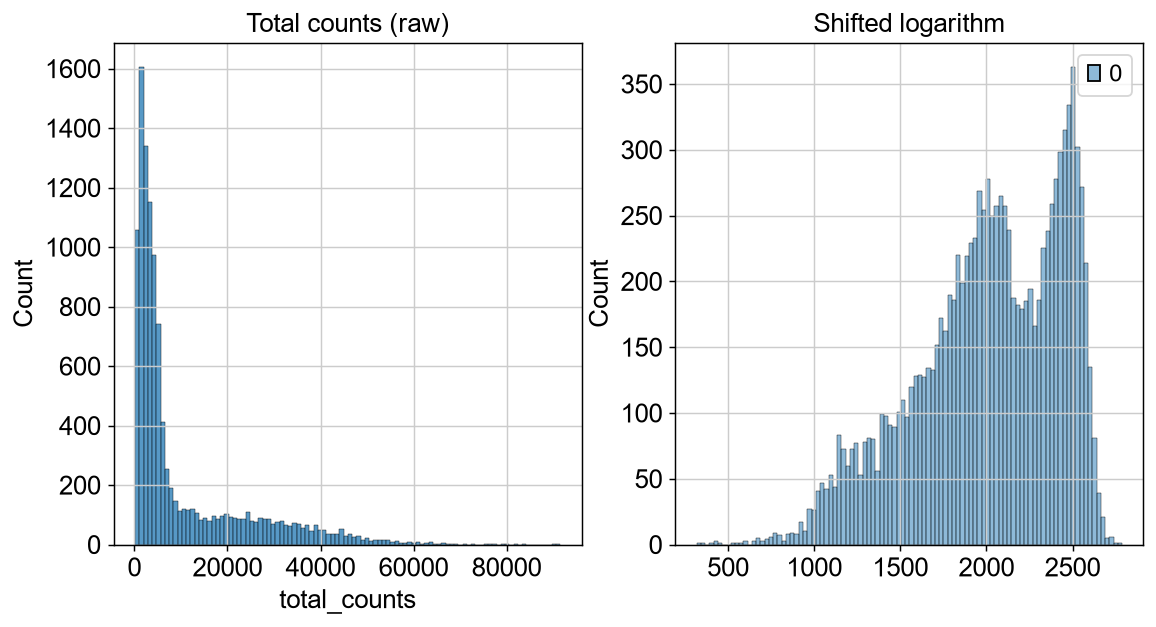

In [30]:
adata.layers["counts"] = adata.X.copy()

sc.pp.normalize_total(adata, target_sum=None)
sc.pp.log1p(adata)

fig, axes = plt.subplots(1, 2, figsize=(10, 5))
sns.histplot(adata.obs["total_counts"], bins=100, kde=False, ax=axes[0])
axes[0].set_title("Total counts (raw)")
sns.histplot(adata.X.sum(1), bins=100, kde=False, ax=axes[1])
axes[1].set_title("Shifted logarithm")
save_fig(6, "normalisation_total_counts_vs_log", fig)
plt.show()

## Feature selection, PCA and embedding

extracting highly variable genes
    finished (0:00:00)
saved output\figures\07_highly_variable_genes.png


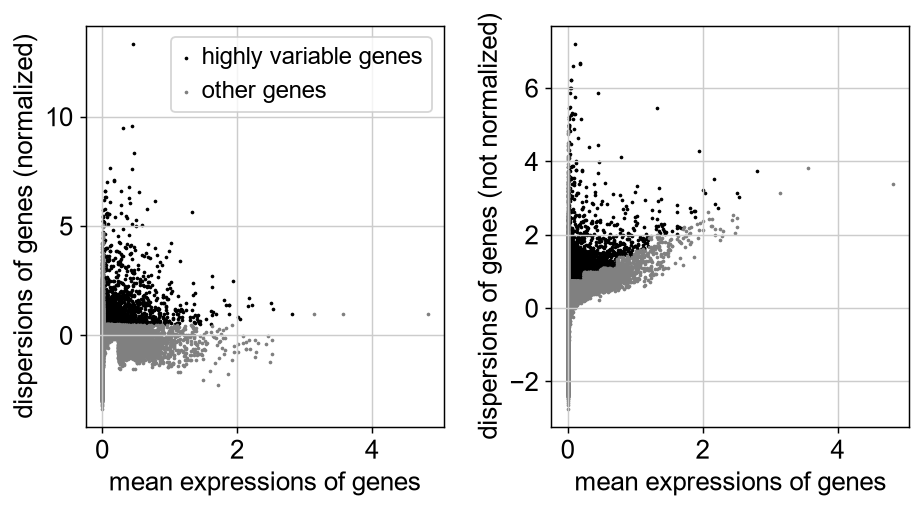

In [39]:
sc.pp.highly_variable_genes(adata)

hvg_axes = sc.pl.highly_variable_genes(adata, show=False)
save_fig(7, "highly_variable_genes", hvg_axes)

computing PCA
    with n_comps=50
    finished (0:00:01)
saved output\figures\08_pca_variance_ratio.png


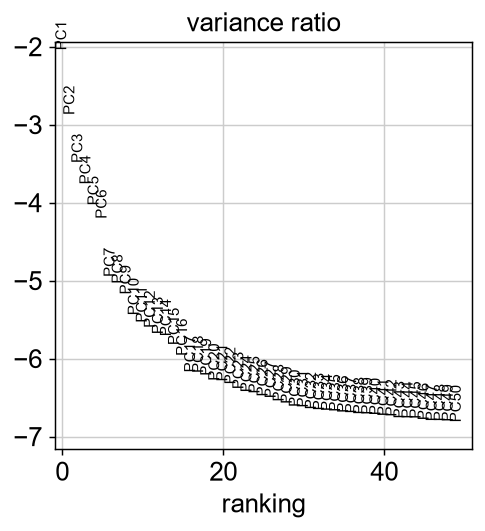

In [40]:
sc.tl.pca(adata)

variance_axes = sc.pl.pca_variance_ratio(adata, n_pcs=50, log=True, show=False)
save_fig(8, "pca_variance_ratio", variance_axes)

saved output\figures\09_pca_pct_counts_mt.png


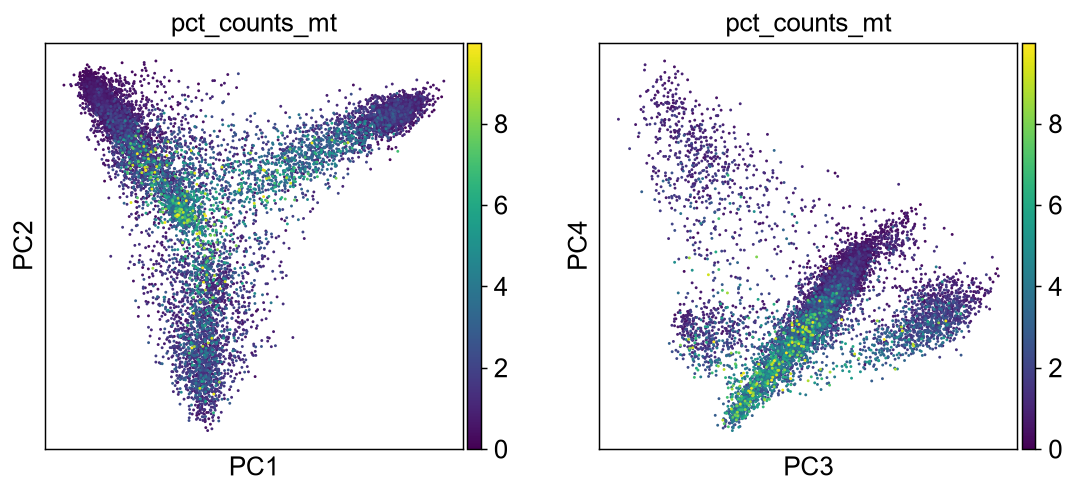

In [41]:
pca_axes = sc.pl.pca(
    adata,
    color="pct_counts_mt",
    dimensions=[(0, 1), (2, 3)],
    ncols=2,
    size=10,
    show=False,
)
save_fig(9, "pca_pct_counts_mt", pca_axes)

In [42]:
sc.pp.neighbors(adata, n_neighbors=15, n_pcs=50)
sc.tl.umap(adata, min_dist=0.2, random_state=12344321)

adata

computing neighbors
    using 'X_pca' with n_pcs = 50
    finished (0:00:01)
computing UMAP
    finished (0:00:04)


AnnData object with n_obs × n_vars = 11252 × 23973
    obs: 'dataset_name', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_20_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb', 'log1p_total_counts_hb', 'pct_counts_hb', 'leiden'
    var: 'mt', 'ribo', 'hb', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'highly_variable', 'means', 'dispersions', 'dispersions_norm'
    uns: 'log1p', 'hvg', 'pca', 'neighbors', 'umap', 'dataset_name_colors', 'leiden', 'leiden_colors'
    obsm: 'X_pca', 'X_umap'
    varm: 'PCs'
    obsp: 'distances', 'connectivities'
    layers: None (.X), 'counts'

saved output\figures\10_umap_dataset_name.pdf


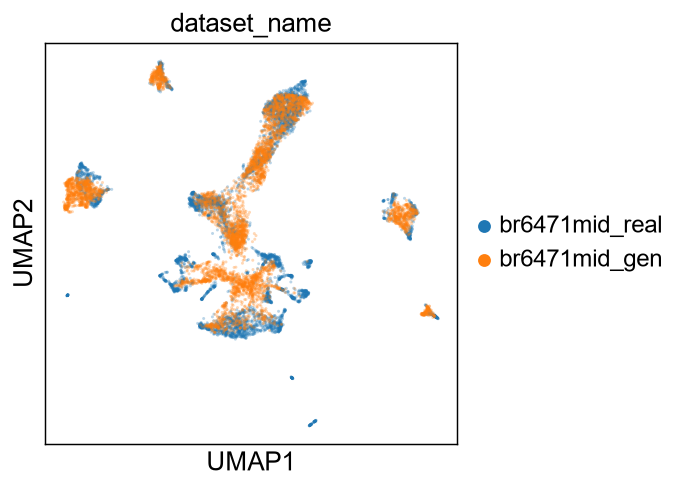

In [43]:
umap_axes = sc.pl.umap(adata, color=["dataset_name"], alpha=0.3, show=False)
save_fig(10, "umap_dataset_name", umap_axes, ext="pdf")

## Joint Leiden clustering

Clustering the concatenated object gives one label set shared by both datasets, which is
what makes the downstream per-cluster comparison meaningful.

In [44]:
# 25-colour palette, keyed by cluster label so colours are stable across plots
my_color25 = [
    "#e6194B", "#3cb44b", "#ffe119", "#4363d8", "#f58231",
    "#911eb4", "#42d4f4", "#f032e6", "#adff2f", "#469990",
    "#000080", "#9A6324", "#800000", "#808000", "#2f4f4f",
    "#7b68ee", "#483d8b", "#aaffc3", "#cd853f", "#005000",
    "#f5deb3", "#ee82ee", "#dcbeff", "#a9a9a9", "#000000",
]
color25 = {str(ii): c for ii, c in enumerate(my_color25)}
color25_num = {ii: c for ii, c in enumerate(my_color25)}

running Leiden clustering
    finished (0:00:05)
saved output\figures\11_umap_leiden_joint.png


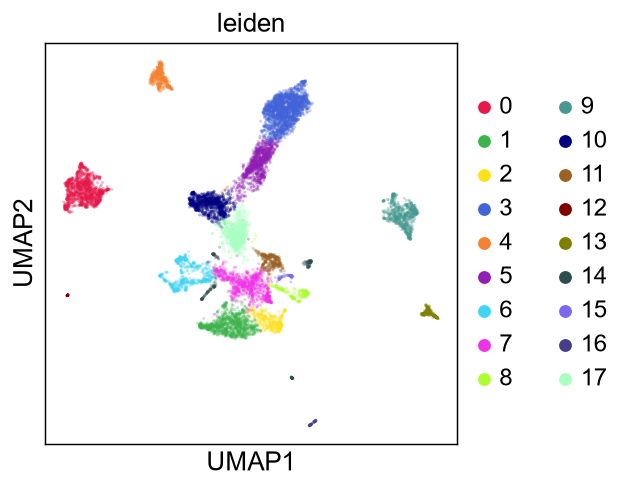

In [45]:
sc.tl.leiden(adata, flavor="igraph", n_iterations=100, resolution=0.7)

umap_axes = sc.pl.umap(adata, color=["leiden"], alpha=0.3, palette=color25, show=False)
save_fig(11, "umap_leiden_joint", umap_axes)

## Export for downstream monocle3 analysis

In [46]:
adata.write_h5ad(out_dir / "adata_br6471mid_real_and_gen_for_monocle3.h5ad")
adata[adata.obs["dataset_name"] == "br6471mid_real", :].write_h5ad(
    out_dir / "adata_br6471mid_real_for_monocle3.h5ad"
)

## Differential expression across all cells

Wilcoxon rank-sum test of each cluster against the rest, on both datasets pooled.
Cluster 15 is dropped here because it is absent from the generated data.

ranking genes


c:\Users\4461373\Python_projects\.venv\Lib\site-packages\scanpy\tools\_rank_genes_groups.py:829: ImplicitModificationWarning: Trying to modify attribute `._uns` of view, initializing view as actual.
  adata.uns[key_added] = {}


    finished (0:00:17)
saved output\figures\12_top25_dea_all_cells.png


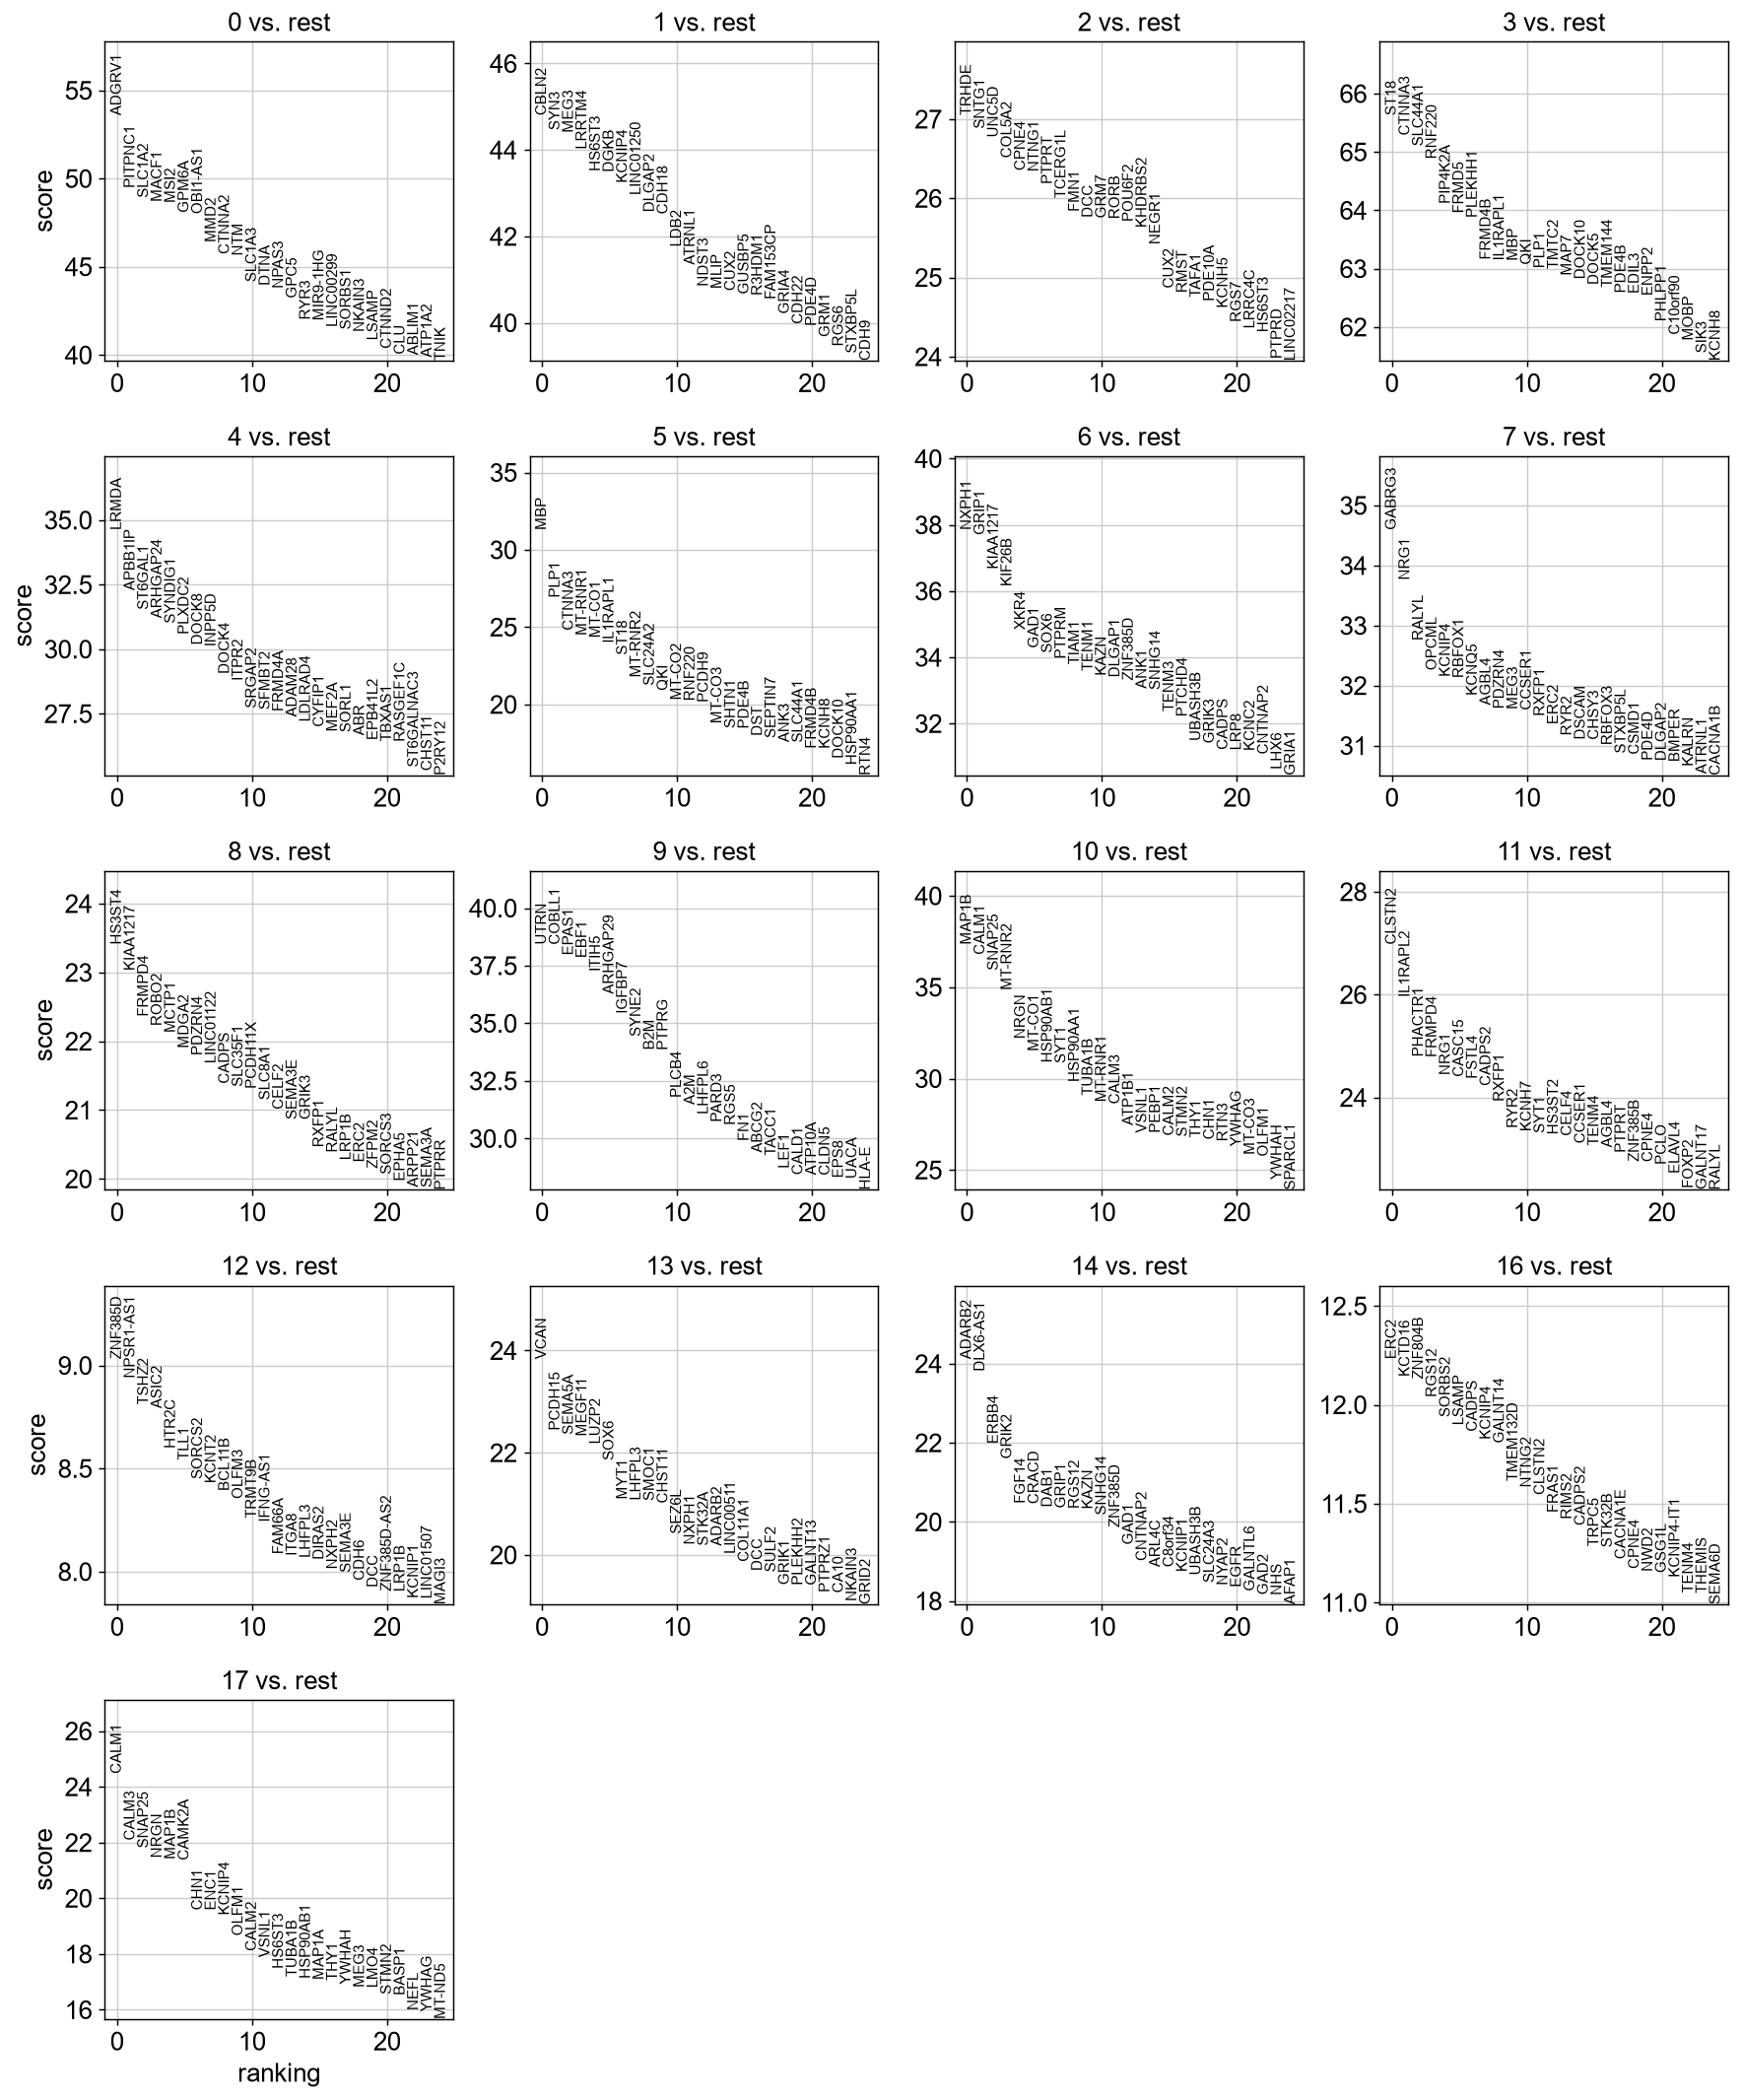

In [47]:
adata_minus_cl15 = adata[adata.obs["leiden"] != "15", :]

sc.tl.rank_genes_groups(
    adata_minus_cl15, groupby="leiden", method="wilcoxon", key_added="dea_leiden"
)

dea_axes = sc.pl.rank_genes_groups(
    adata_minus_cl15, n_genes=25, sharey=False, key="dea_leiden", show=False
)
save_fig(12, "top25_dea_all_cells", dea_axes)

## Per-dataset differential expression

The comparison is restricted to the clusters that are populated in *both* datasets
(`cluster_2_use`); clusters present only in the real data cannot be compared. Each
dataset is subset once and tested once, so the two `dea_leiden` results are like-for-like.

In [48]:
# Cluster occupancy in the generated data motivates which clusters are comparable
adata.obs.groupby("dataset_name", observed=True)["leiden"].value_counts().unstack(0).sort_index()

dataset_name,br6471mid_real,br6471mid_gen
leiden,,
0,424,823
1,705,274
2,290,71
3,1179,829
4,198,302
5,282,678
6,370,241
7,168,728
8,202,39


In [49]:
cluster_2_use = [
    "0", "1", "2", "3", "4", "5", "6", "7",
    "8", "9", "10", "11", "13", "14", "17",
]

adata_br6471mid_real = adata[
    (adata.obs["dataset_name"] == "br6471mid_real") & adata.obs["leiden"].isin(cluster_2_use), :
]
adata_br6471mid_gen = adata[
    (adata.obs["dataset_name"] == "br6471mid_gen") & adata.obs["leiden"].isin(cluster_2_use), :
]

adata_br6471mid_real.shape, adata_br6471mid_gen.shape

((5464, 23973), (5638, 23973))

c:\Users\4461373\Python_projects\.venv\Lib\site-packages\scanpy\plotting\_utils.py:509: ImplicitModificationWarning: Trying to modify attribute `._uns` of view, initializing view as actual.
  adata.uns[f"{value_to_plot}_colors"] = colors_list


saved output\figures\13_umap_dge_br6471mid_real.pdf
saved output\figures\14_umap_dge_br6471mid_gen.pdf


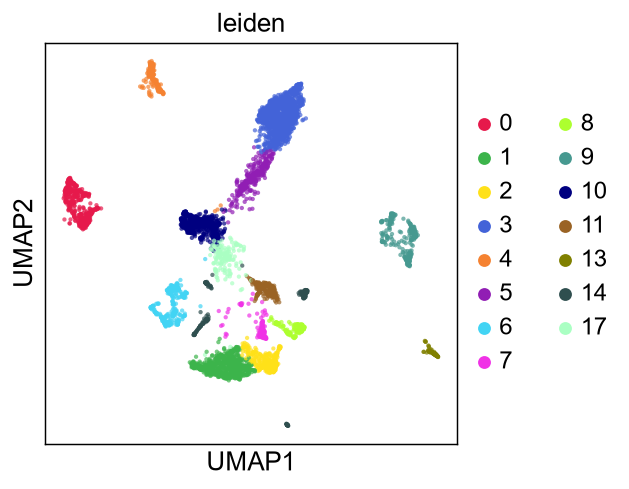

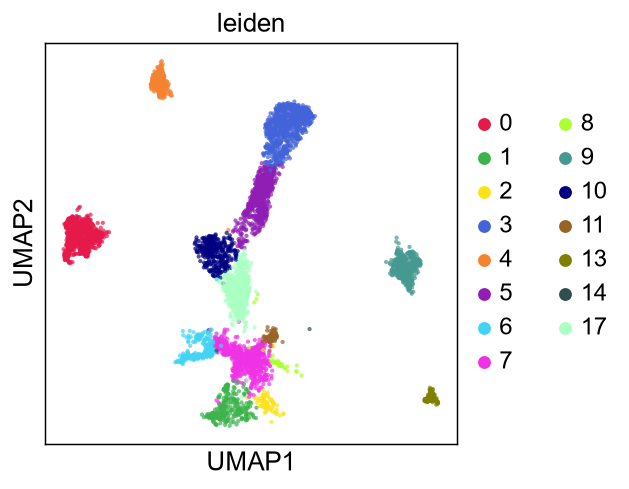

In [50]:
for index, (name, subset) in enumerate(
    [
        ("br6471mid_real", adata_br6471mid_real),
        ("br6471mid_gen", adata_br6471mid_gen),
    ],
    start=13,
):
    umap_axes = sc.pl.umap(
        subset, color=["leiden"], alpha=0.7, palette=color25, show=False
    )
    save_fig(index, f"umap_dge_{name}", umap_axes, ext="pdf")

ranking genes
    finished (0:00:08)
saved output\figures\15_top25_dea_br6471mid_real.png
ranking genes
    finished (0:00:08)
saved output\figures\16_top25_dea_br6471mid_gen.png


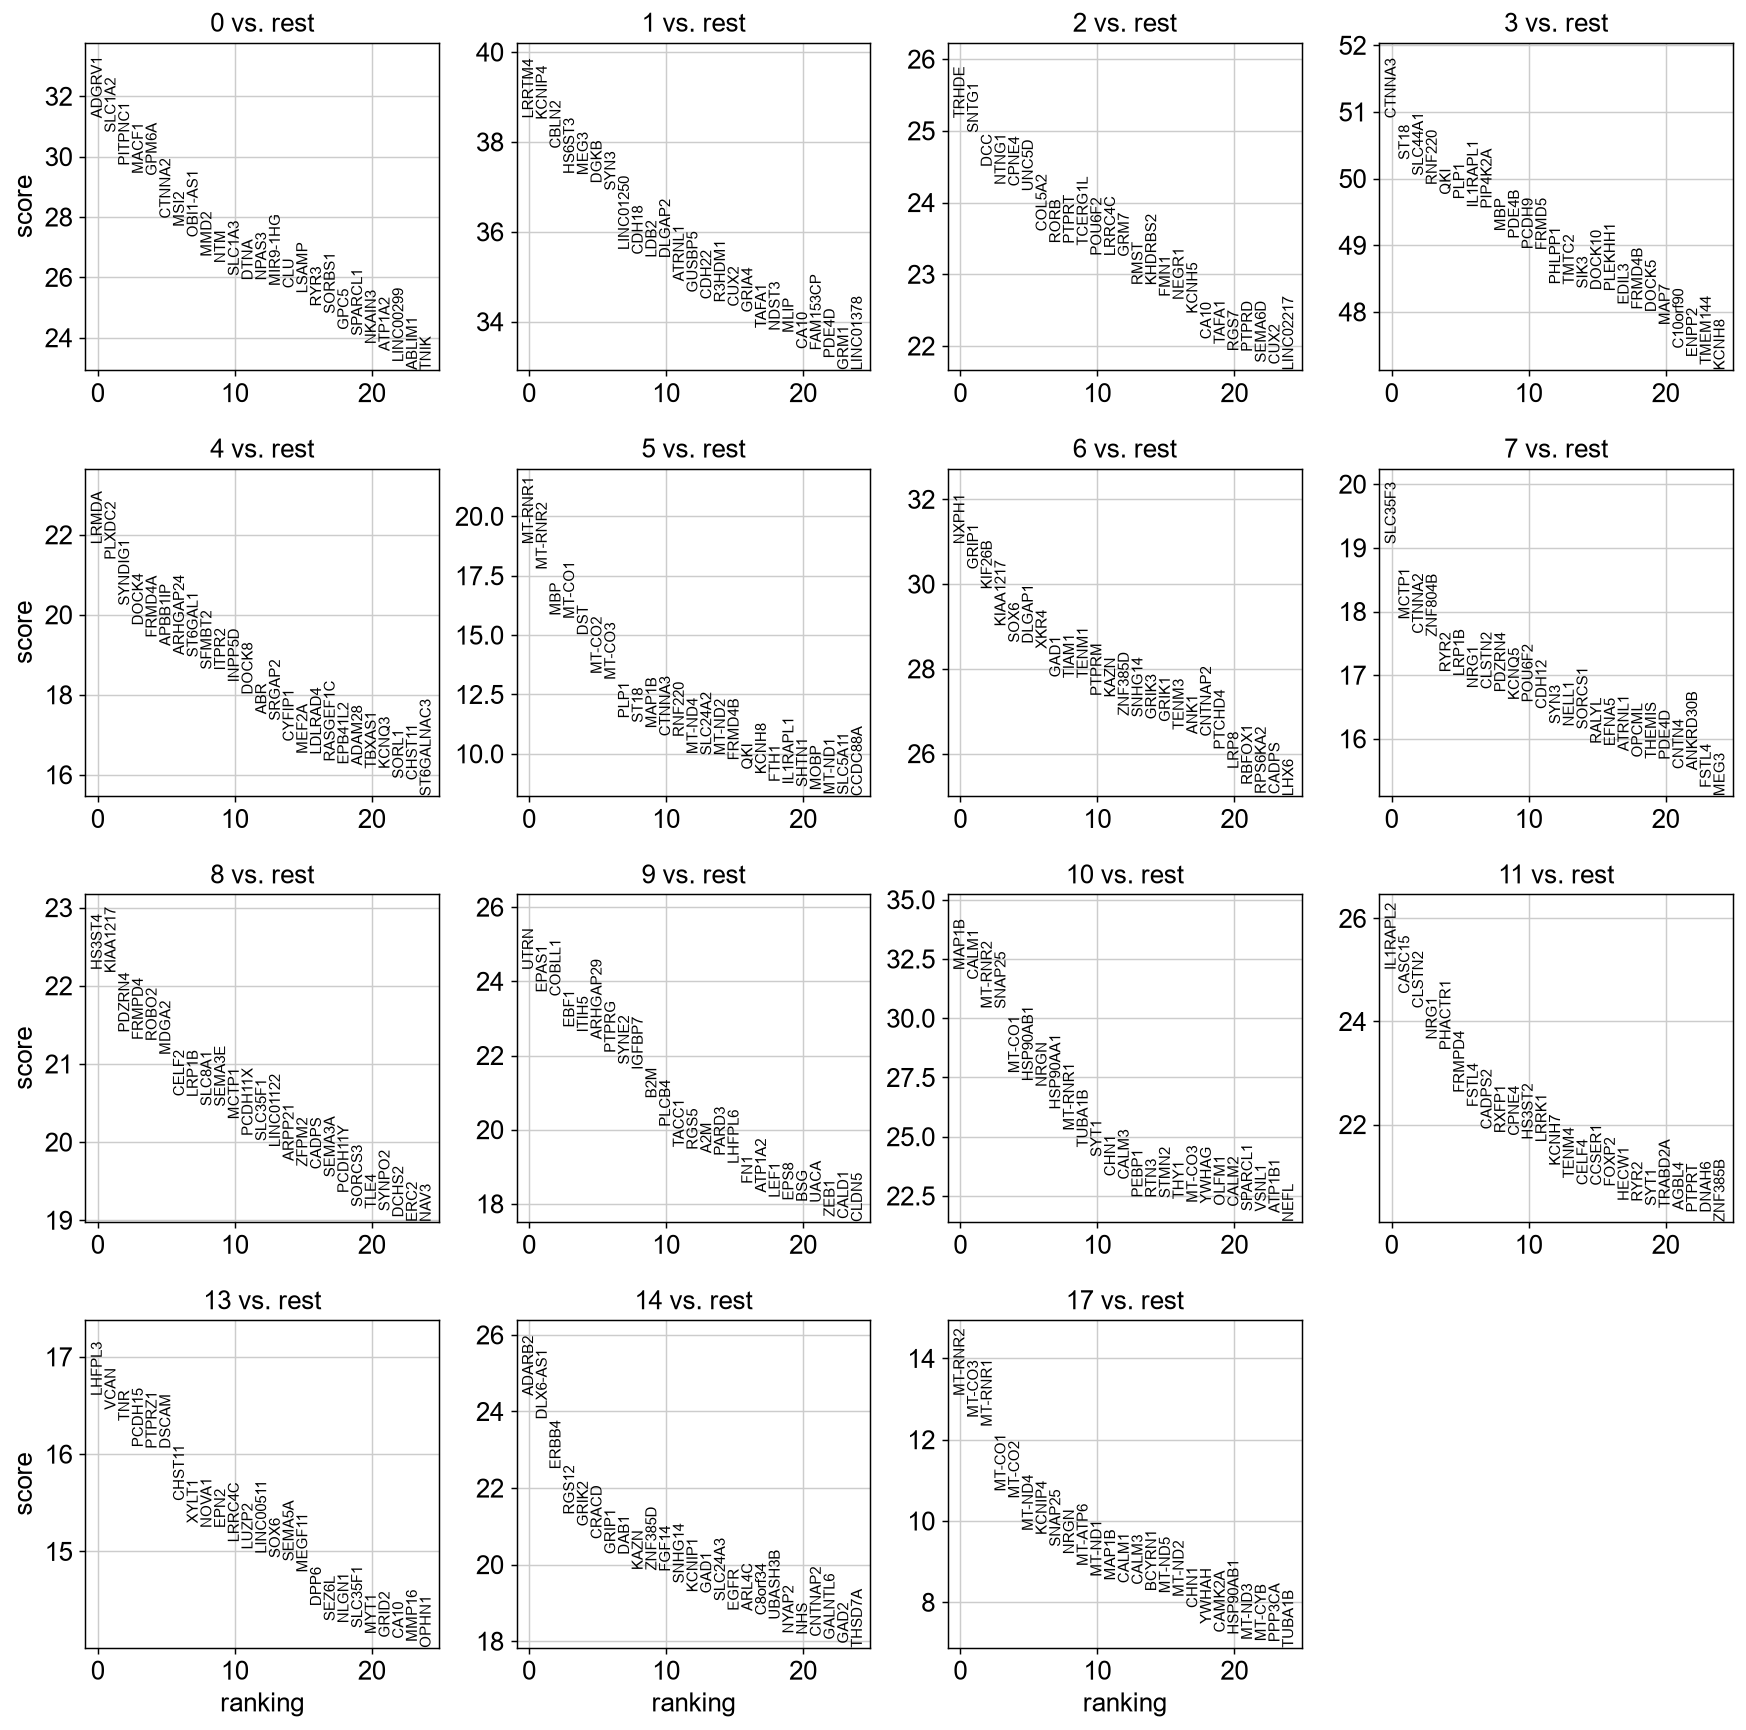

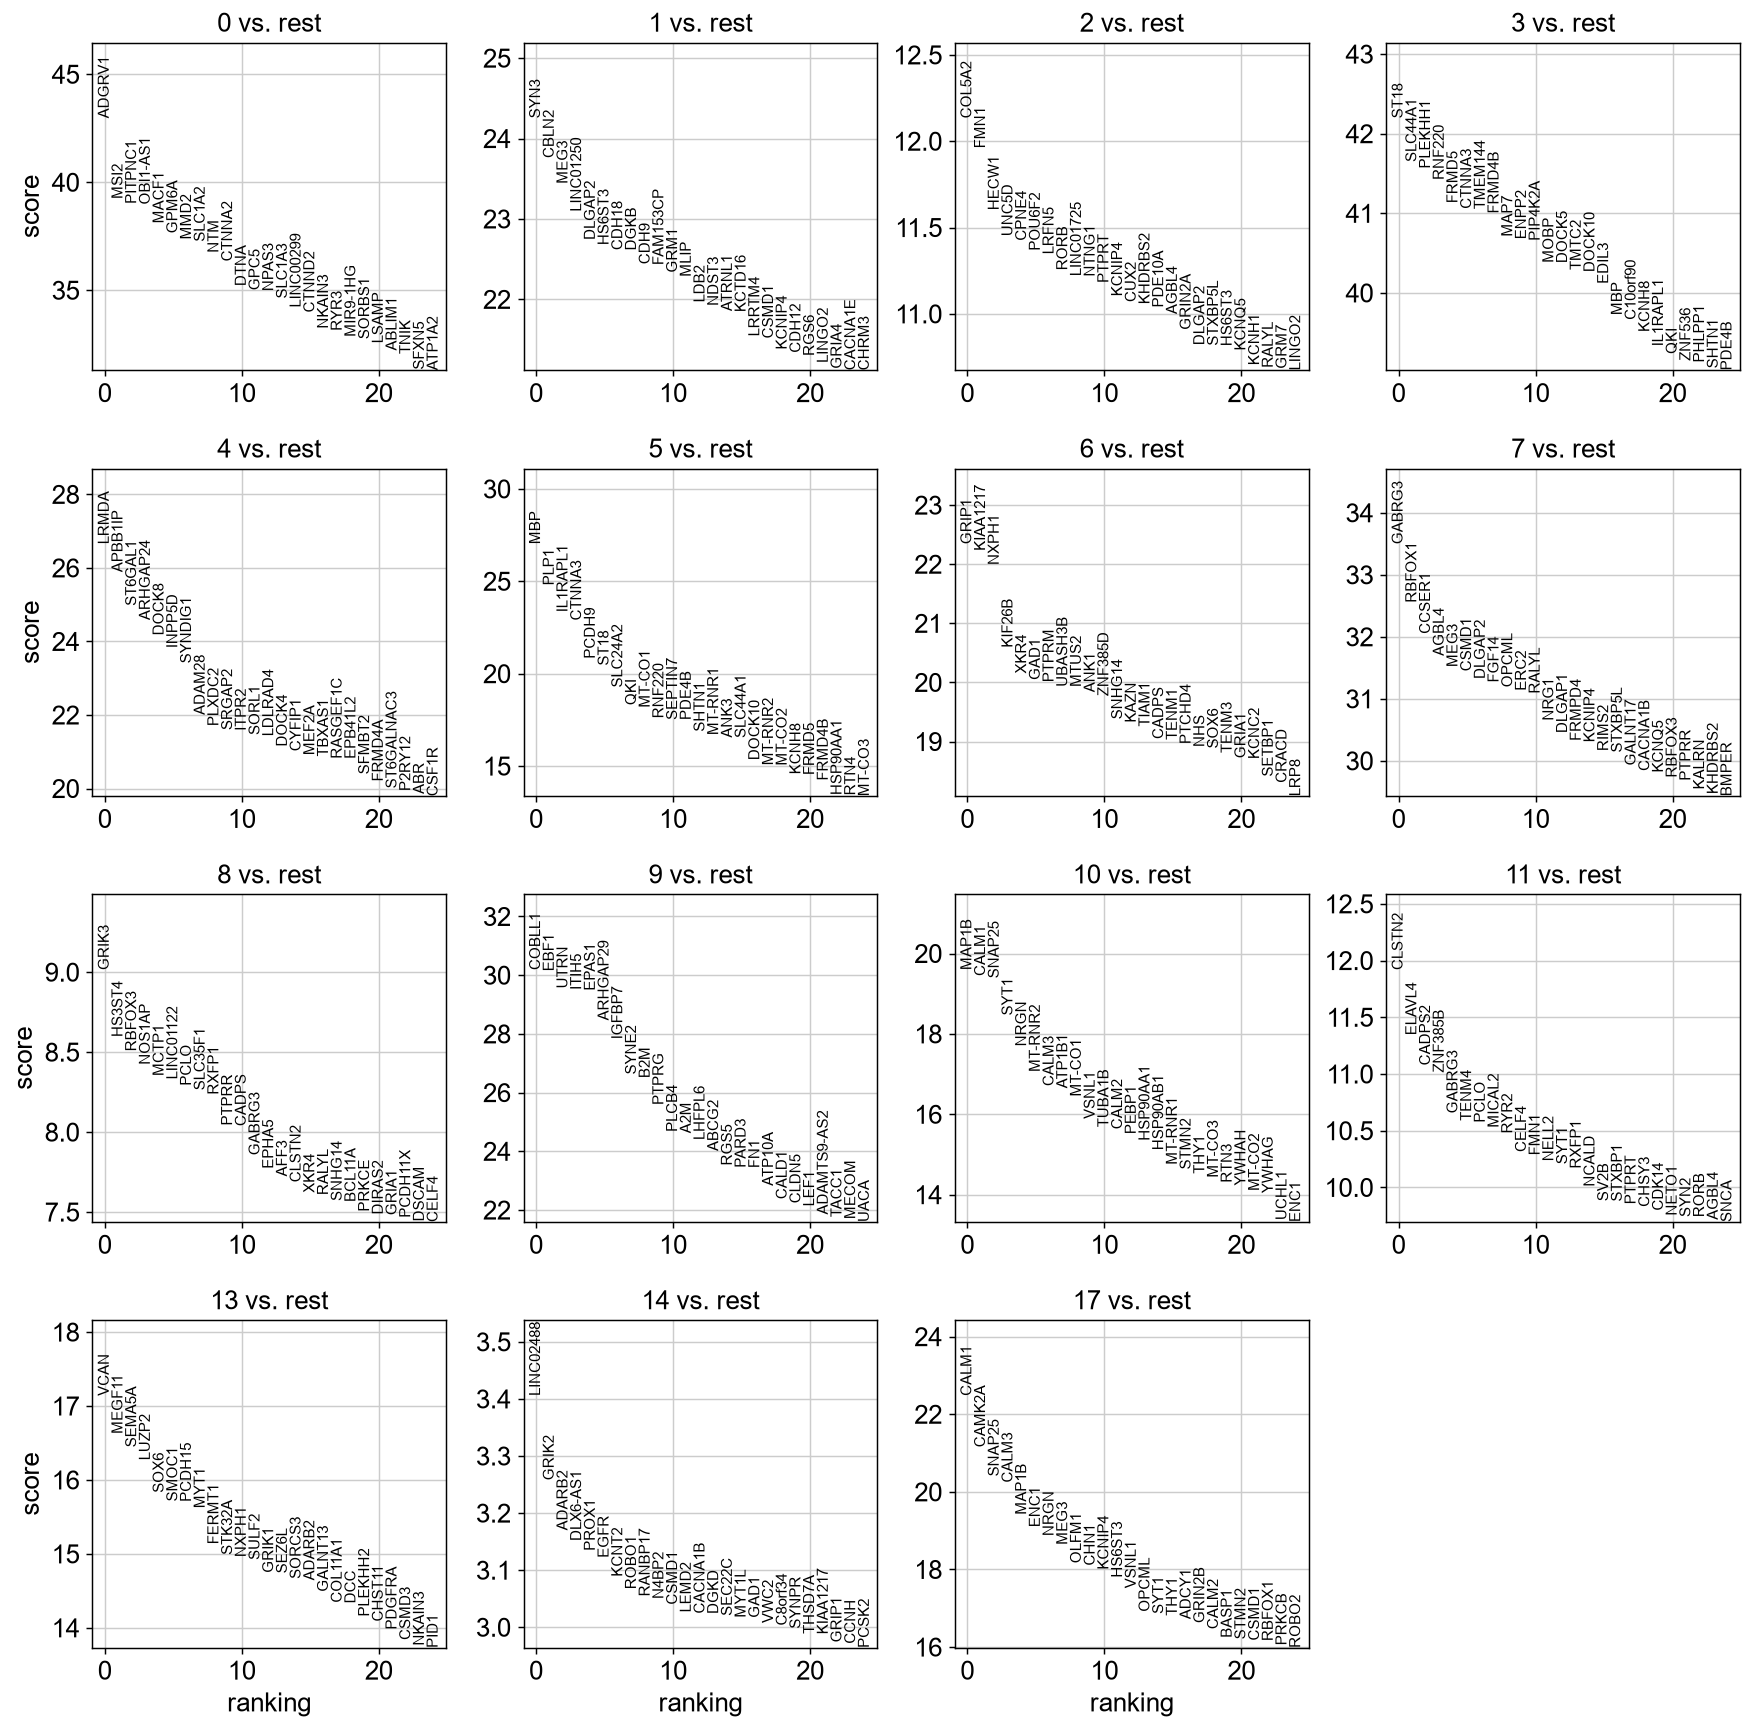

In [51]:
for index, (name, subset) in enumerate(
    [
        ("br6471mid_real", adata_br6471mid_real),
        ("br6471mid_gen", adata_br6471mid_gen),
    ],
    start=15,
):
    sc.tl.rank_genes_groups(
        subset, groupby="leiden", method="wilcoxon", key_added="dea_leiden"
    )
    dea_axes = sc.pl.rank_genes_groups(
        subset, n_genes=25, sharey=False, key="dea_leiden", show=False
    )
    save_fig(index, f"top25_dea_{name}", dea_axes)

## Differential expression tables

In [20]:
df_dea_br6471mid_real = sc.get.rank_genes_groups_df(
    adata_br6471mid_real, group=None, key="dea_leiden"
)
df_dea_br6471mid_gen = sc.get.rank_genes_groups_df(
    adata_br6471mid_gen, group=None, key="dea_leiden"
)

df_dea_br6471mid_real.to_csv(tbl_dir / "df_dea_br6471mid_real.csv")
df_dea_br6471mid_gen.to_csv(tbl_dir / "df_dea_br6471mid_gen.csv")

df_dea_br6471mid_real.head()

,group,names,scores,logfoldchanges,pvals,pvals_adj
0,0,ADGRV1,31.270760,6.635320,1.165955e-214,2.795145e-210
1,0,SLC1A2,30.794050,5.407028,3.147930e-208,3.773266e-204
2,0,PITPNC1,29.705507,4.539458,6.518662e-194,5.209063e-190
3,0,MACF1,29.430395,2.433589,2.243732e-190,1.344725e-186
4,0,GPM6A,29.366749,2.618150,1.460531e-189,7.002662e-186


### Mean adjusted p-value of the top 1000 genes

Per cluster, the mean `pvals_adj` over that cluster's 1000 most significant genes, then
averaged across clusters. A rough summary of how strongly each dataset separates its
clusters.

In [21]:
kk = 1000


def mean_top_pval(df, kk=kk):
    """Mean adjusted p-value of the top `kk` genes, per cluster."""
    return (
        df.sort_values("pvals_adj")
        .groupby("group", observed=True)
        .head(kk)
        .groupby("group", observed=True)["pvals_adj"]
        .mean()
    )


mean_pvals = pd.DataFrame(
    {
        "real": mean_top_pval(df_dea_br6471mid_real),
        "generated": mean_top_pval(df_dea_br6471mid_gen),
    }
)
print(mean_pvals.mean().rename("mean across clusters"))
mean_pvals

real         0.000005
generated    0.067805
Name: mean across clusters, dtype: float64


,real,generated
group,,
0,1.622966e-28,2.447277e-26
1,4.621930e-78,6.322281e-28
2,2.742963e-34,7.029305e-09
3,5.121957e-94,3.633454e-42
4,6.280929e-15,3.598213e-13
5,4.512476e-21,1.971394e-25
6,3.773454e-23,3.492379e-14
7,4.706768e-16,1.670177e-84
8,1.546808e-18,1.645105e-02


## Gene set overlap: real vs generated

For each cluster, the differentially expressed gene set from the generated data is
compared with the set from the real data. The p-value is the hypergeometric survival
function $$P(\text{overlap} \ge x)$$ against a universe of all measured genes, which is
the one-sided Fisher exact test for the same 2x2 table.

In [22]:
clusters = list(adata_br6471mid_gen.obs["leiden"].value_counts().sort_index().index)
n_genes_universe = adata_br6471mid_gen.shape[1]


def venn_grid(gene_sets, M, suptitle, index, name, ext="pdf", figsize=(20, 13)):
    """Grid of per-cluster Venn diagrams with hypergeometric overlap p-values.

    gene_sets: sequence of (cluster_label, generated_set, real_set).
    M: size of the gene universe.
    index, name, ext: passed to `save_fig`.
    """
    fig, axes = plt.subplots(3, 5, figsize=figsize)
    axes_flat = axes.flatten()

    for ax, (cl, set_gen, set_real) in zip(axes_flat, gene_sets):
        n, N = len(set_gen), len(set_real)
        x = len(set_gen & set_real)
        p_val = hypergeom.sf(x - 1, M, n, N) if n and N else np.nan

        venn2([set_gen, set_real], set_labels=("Generated", "Real"), ax=ax)
        ax.set_title(
            f"Cluster {cl} vs rest\nHypergeometric P = {p_val:.2e}",
            fontsize=12,
            fontweight="bold",
        )

    for ax in axes_flat[len(gene_sets):]:
        ax.axis("off")  # hide unused panels

    plt.suptitle(suptitle, fontsize=20)
    plt.tight_layout()
    save_fig(index, name, fig, ext=ext)
    plt.show()

### Top 1000 ranked genes per cluster

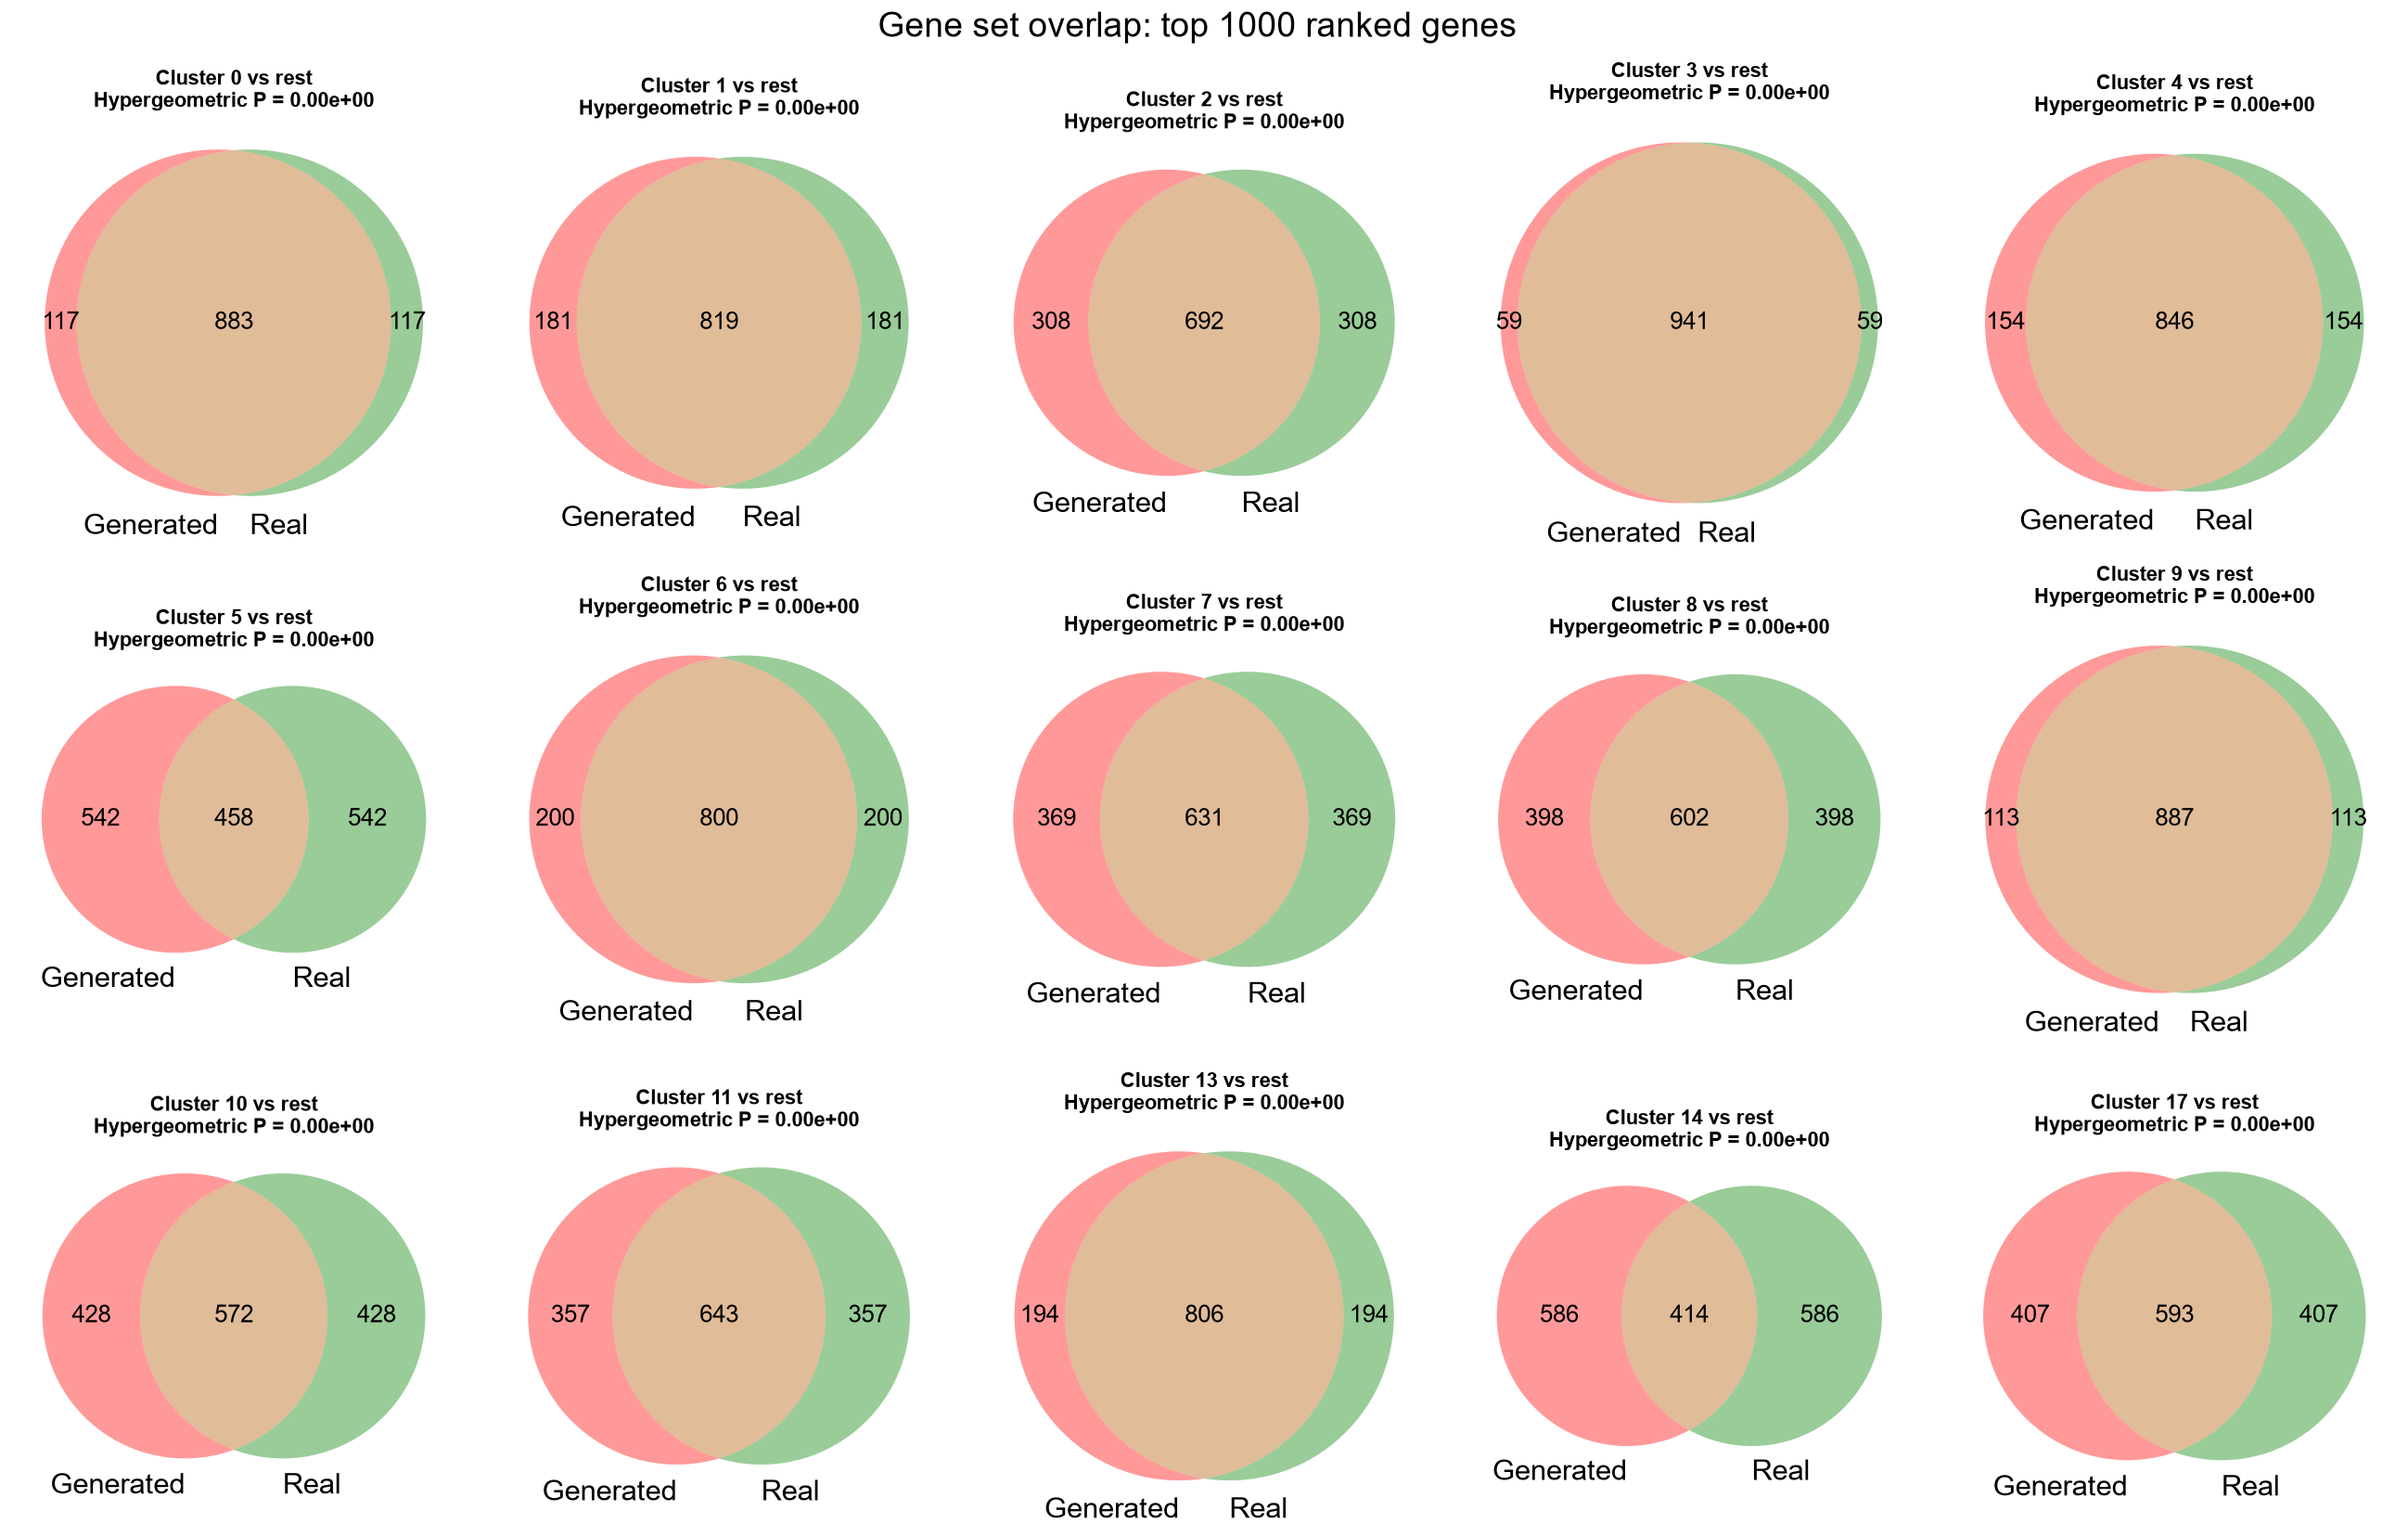

In [23]:
top_sets = [
    (
        cl,
        set(adata_br6471mid_gen.uns["dea_leiden"]["names"][cl][:kk]),
        set(adata_br6471mid_real.uns["dea_leiden"]["names"][cl][:kk]),
    )
    for cl in clusters
]

venn_grid(
    top_sets,
    M=n_genes_universe,
    suptitle=f"Gene set overlap: top {kk} ranked genes",
    index=17,
    name=f"venn_top{kk}_genes",
)

### All significant genes per cluster (adjusted p < 0.05)

Caveat: these sets run to several thousand genes out of a ~24,000-gene universe, so the
hypergeometric p-values underflow to 0 for every cluster and carry essentially no
information — sets that large are forced to overlap heavily. The Venn counts and the
top-1000 panel above are the more informative comparison.

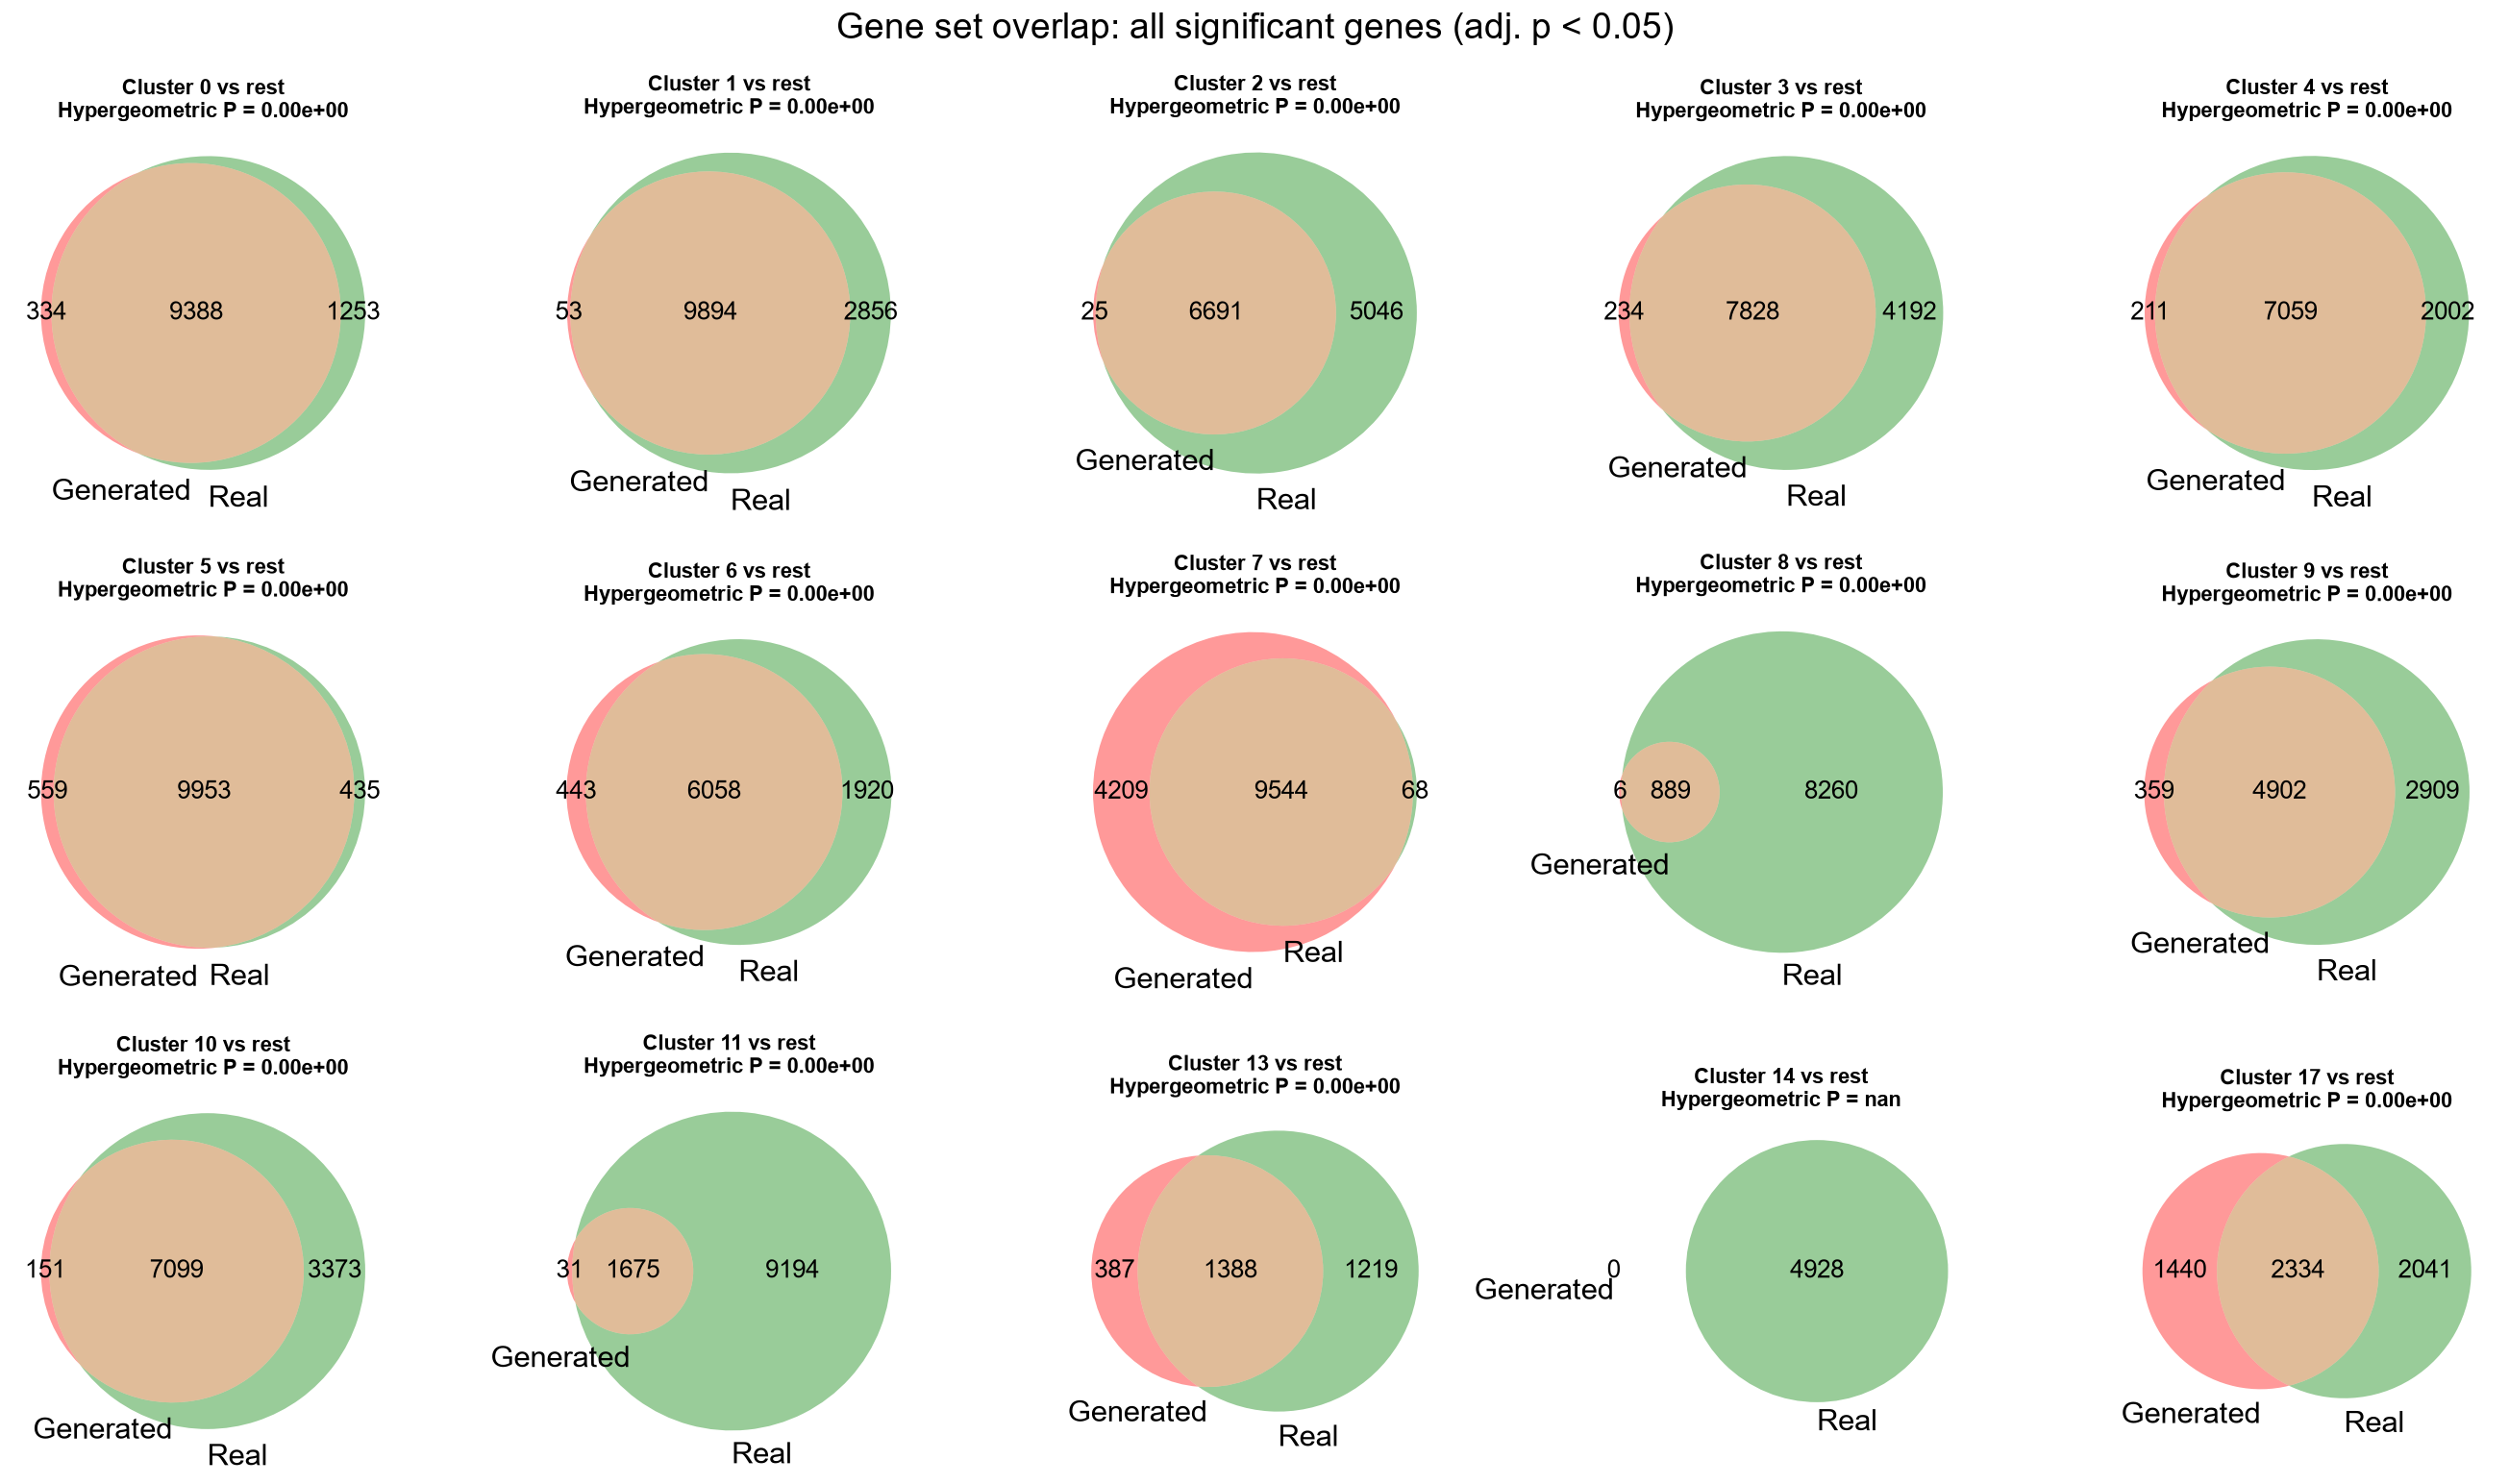

In [24]:
df_sig_real = df_dea_br6471mid_real.loc[df_dea_br6471mid_real["pvals_adj"] < 0.05, :]
df_sig_gen = df_dea_br6471mid_gen.loc[df_dea_br6471mid_gen["pvals_adj"] < 0.05, :]

sig_sets = [
    (
        cl,
        set(df_sig_gen.loc[df_sig_gen["group"] == cl, "names"]),
        set(df_sig_real.loc[df_sig_real["group"] == cl, "names"]),
    )
    for cl in clusters
]

venn_grid(
    sig_sets,
    M=n_genes_universe,
    suptitle="Gene set overlap: all significant genes (adj. p < 0.05)",
    index=18,
    name="venn_all_significant_genes",
    figsize=(20, 12),
)